# ToDo

* save the outputs in a different folder

# Packages

In [2]:
import cell2location
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

import torch, scvi
from scipy import sparse # Dealing with adata data dyptes numbers

import torch
# torch.set_float32_matmul_precision("high")  # or "medium"
# to deal with this warning
# You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. 
# To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` 
# which will trade-off precision for performance. For more details, read 
# https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision

## SC: GPU

In [3]:
# # SC for GPU
# import torch

# print("Torch version:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())
# print("CUDA version (torch):", torch.version.cuda)
# print("GPU count:", torch.cuda.device_count())

# if torch.cuda.is_available():
#     print("Current device:", torch.cuda.current_device())
#     print("Device name:", torch.cuda.get_device_name(0))


In [4]:

# print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

# Data

## Variables

In [22]:
N_cells_loc  = 1
dec_alpha    = 100
gpus_dev     = 4


epoch_num    = 200 # First run was about 200 epochs. Let's try 500 epochs to see if it improves the results.
batch_num    = 8192 #4096, 8192, 16384, 32768
export_num   = 500 # 1k was too much for the GPU memory

In [23]:
# Selected level of annotation for training the model.
level = 1
levels = ["cell_type_lvl1", "cell_type_lvl2", "cell_type_lvl3"]

level_short = {
    "cell_type_lvl1": "lvl1",
    "cell_type_lvl2": "lvl2",
    "cell_type_lvl3": "lvl3",
}

current_level = levels[level]
lvl_name_short =level_short[current_level]

## Locations

In [24]:
# Project folder
# proj_folder   = Path("/Users/janzules/Roselab/Spatial/CAR_T/")
proj_folder   = Path("/coh_labs/yunroseli/Jona/CAR-T/")
c2l_folder     = proj_folder / "results/cell2location/"

# Files for training and mapping
input_folder   = c2l_folder / "C2L_inputs"

figures_folder = proj_folder / "figures/cell2location/mapping"


# ref_loc        = input_folder / "ref_adata_c2l_model.h5ad"
spatial_loc   = input_folder / "spatial_sdata_c2l_model.h5ad"

# Output location - Not sure what these are for
ref_run_name   = c2l_folder / f"reference_signatures_{lvl_name_short}"
run_name       = c2l_folder / f"c2l_{lvl_name_short}_epochs_{epoch_num}_Ncells{N_cells_loc}_decalpha_{dec_alpha}"

# After training
trained_sc_data_file = input_folder / f"sc_with_signatures_{lvl_name_short}.h5ad"
predicted_cells_file = input_folder / f"predicted_cells_{lvl_name_short}_epochs_{epoch_num}_Ncells{N_cells_loc}_decalpha_{dec_alpha}.h5ad"

In [25]:
# Load data
adata_vis = sc.read_h5ad(spatial_loc)
adata_ref = sc.read_h5ad(trained_sc_data_file)

In [26]:
adata_ref.uns['mod']['factor_names']

array(['B', 'CD4_T', 'CD8_T', 'Cancer_cell', 'Classical_Mono',
       'Endothelial', 'Erythrocyte', 'Fibroblast', 'Intermediate_Mac',
       'M1_like_Mac', 'M2_like_Mac', 'N1_like_Neu', 'N2_like_Neu', 'NK',
       'NKT', 'Nonclassical_Mono', 'Treg', 'cDC', 'pDC'], dtype=object)

In [27]:
# proj_folder   = Path("/home/janzules/spatial/CAR-T/data/cell2location")
# input_folder  = proj_folder / "cell2location_inputs"

# # ref_loc       = input_folder / "ref_adata_c2l_model.h5ad"  saved adata_file with the training at:
# spatial_loc   = input_folder / "spatial_sdata_c2l_model.h5ad"

# # Output location
# ref_run_name   = proj_folder / "reference_signatures"
# run_name       = proj_folder / "cell2location_map"

# # After training
# adata_ref_file     = ref_run_name / "sc_with_signatures.h5ad" # 

## Data Prep - sdata

In [28]:

# # Creating the column that will match the sc reference
# adata_vis.obs['treatment'] = adata_vis.obs['condition'].astype(str)

# # Convert tumor_loc robustly: category -> string -> numeric
# adata_vis.obs['tumor_loc'] = pd.to_numeric(
#     adata_vis.obs['tumor_loc'].astype(str).str.strip(),
#     errors='coerce'
# ).astype('Int64')  # nullable integer dtype

# tumor_locations = [1, 2]

# for tumor in tumor_locations:
#     suffix = f"_Tu{tumor}"
#     tum_loc_mask = adata_vis.obs["tumor_loc"].eq(tumor)

#     adata_vis.obs.loc[tum_loc_mask, 'treatment'] = (
#         adata_vis.obs.loc[tum_loc_mask, 'treatment']
#         .str.replace(r"T72", "TAG72", regex=True)
#         + suffix
#     )


## Loading sdata parameters

In [29]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B,CD4_T,CD8_T,Cancer_cell,Classical_Mono
gene_id,,,,,
ENSMUSG00000051951,0.029603,0.017300,0.011325,0.010806,0.000611
ENSMUSG00000025902,0.022129,0.012658,0.001919,0.000348,0.000076
ENSMUSG00000025903,0.168787,0.388103,0.279053,0.086015,0.251908
ENSMUSG00000033813,0.215083,0.738445,0.530219,0.589549,0.514592
ENSMUSG00000002459,0.574192,0.309674,0.020432,0.005635,0.000237


# Training

In [30]:
# find shared genes and subset both anndata and reference signatures
# MT was removed from vis data, and the infe_aver selected the most relevant genes for annotating
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)

In [31]:
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="TMA")

In [32]:
print(f"The amount of genes in visium data: {adata_vis.shape[1]}")
print(f"The amount of genes in reference signatures: {inf_aver.shape[0]}")

The amount of genes in visium data: 12176
The amount of genes in reference signatures: 12176


In [33]:
# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=N_cells_loc,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=dec_alpha
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.1.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'TMA',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   4    │
│         n_cells          │ 425859 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   1    │
│          n_vars          │ 12176  │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['TMA'] │   F07839   │          0          │
│                  │   F07840   │          1          │
│                  │   F08542   │          2          │
│                  │   F08543   │          3          │
└──────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [34]:
# torch.cuda.empty_cache() #Something it calling torch.cuda* function and messing this up
mod.train(
    max_epochs=epoch_num,
    batch_size=batch_num,
    train_size=1,
    lr=0.002,
    num_particles=1,
    # device=gpus_dev, # GPUs to use
    # accelerator="gpu", # GPU
    # strategy="ddp_notebook_find_unused_parameters_true",
    # Distributed Data Parallel (DDP) for multi-GPU training in notebooks.
    # 'find_unused_parameters=True' prevents crashes if some model parameters
    # are not used in every forward pass (common in scvi/cell2location).
    # datasplitter_kwargs={"drop_dataset_tail": True, "drop_last": False}
    # Controls how data batches are split across GPUs:
    # - drop_dataset_tail=True: ensures even splitting across GPUs (avoids DDP errors)
    # - drop_last=False: keeps all data (does not discard final incomplete batch)
)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping 

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


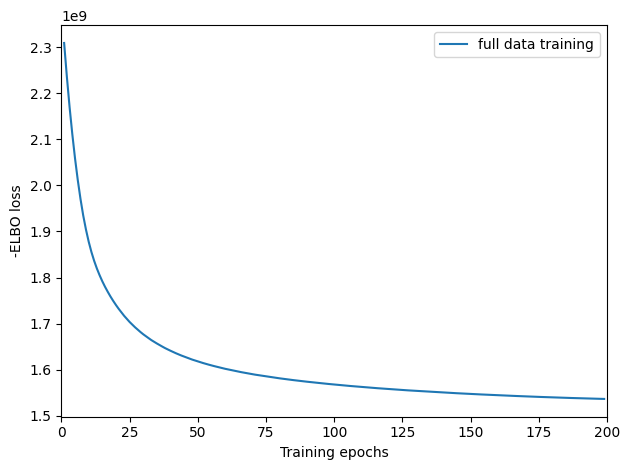

In [35]:
# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1)
plt.legend(labels=['full data training']);
# mod.train(max_epochs=30000,
#           # train using full data (batch_size=None)
#           batch_size=None,
#           # use all data points in training because
#           # we need to estimate cell abundance at all locations
#           train_size=1
#          )

# Exporting

In [36]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_vis = mod.export_posterior(
    adata_vis, 
    sample_kwargs={'num_samples': export_num, 'batch_size': batch_num}, # Originally 1000,
)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...


Sampling local variables, batch:   0%|          | 0/52 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/499 [00:00<?, ?it/s]

In [37]:
# adata_vis = mod.export_posterior(
#     adata_vis,
#     use_quantiles=True,
#     add_to_obsm=["q50"],
#     sample_kwargs={"batch_size": batch_num},
# )

In [38]:
# Save model
mod.save(f"{run_name}", overwrite=True)

In [39]:
# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

# Save anndata object with results
# adata_file = f"{run_name}/sp_{epoch_num}_epochs.h5ad"
adata_vis.write(predicted_cells_file)
# adata_file

In [40]:
predicted_cells_file

PosixPath('/coh_labs/yunroseli/Jona/CAR-T/results/cell2location/C2L_inputs/predicted_cells_lvl2_epochs_200_Ncells1_decalpha_100.h5ad')

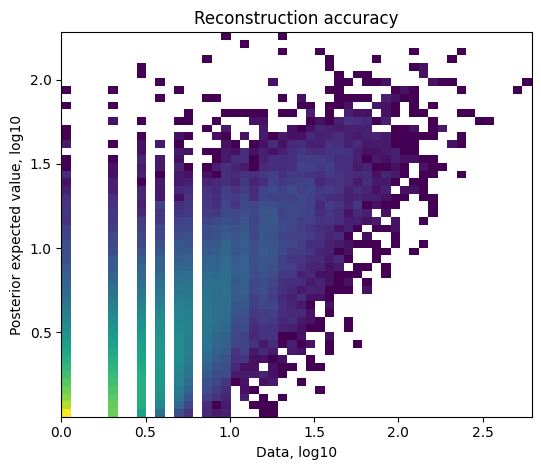

In [41]:
mod.plot_QC()

In [42]:
# mod.plot_spatial_QC_across_batches()

# Data output

In [43]:
# %% Custom QC summary by batch
factor_names = list(adata_vis.uns["mod"]["factor_names"])

adata_vis.obs["c2l_total_abundance"] = np.asarray(
    adata_vis.obsm["means_cell_abundance_w_sf"].sum(axis=1)
).ravel()

rna_col = "total_RNA_counts" if "total_RNA_counts" in adata_vis.obs.columns else "total RNA counts"
batch_col = "TMA"   # switch to "sample" if you want per-sample rather than technical batch

qc_summary = (
    adata_vis.obs
    .groupby(batch_col, observed=True)
    .agg(
        n_obs=("cell_id", "size"),
        median_total_RNA=(rna_col, "median"),
        mean_total_RNA=(rna_col, "mean"),
        median_c2l_total_abundance=("c2l_total_abundance", "median"),
        mean_c2l_total_abundance=("c2l_total_abundance", "mean"),
    )
    .sort_index()
)

qc_summary

,n_obs,median_total_RNA,mean_total_RNA,median_c2l_total_abundance,mean_c2l_total_abundance
TMA,,,,,
F07839,178034,828.0,1068.826634,0.959139,1.077432
F07840,123639,988.0,1408.287353,0.757824,1.068011
F08542,65886,3086.0,3759.149000,1.654732,1.650502
F08543,58300,2506.0,3017.449897,1.368837,1.443483


F07839: RNA median=828.0, RNA mean=1068.8, c2l median=0.9591, c2l mean=1.0774, Spearman(RNA vs c2l)=0.968
F07840: RNA median=988.0, RNA mean=1408.3, c2l median=0.7578, c2l mean=1.0680, Spearman(RNA vs c2l)=0.901
F08542: RNA median=3086.0, RNA mean=3759.1, c2l median=1.6547, c2l mean=1.6505, Spearman(RNA vs c2l)=0.806
F08543: RNA median=2506.0, RNA mean=3017.4, c2l median=1.3688, c2l mean=1.4435, Spearman(RNA vs c2l)=0.898


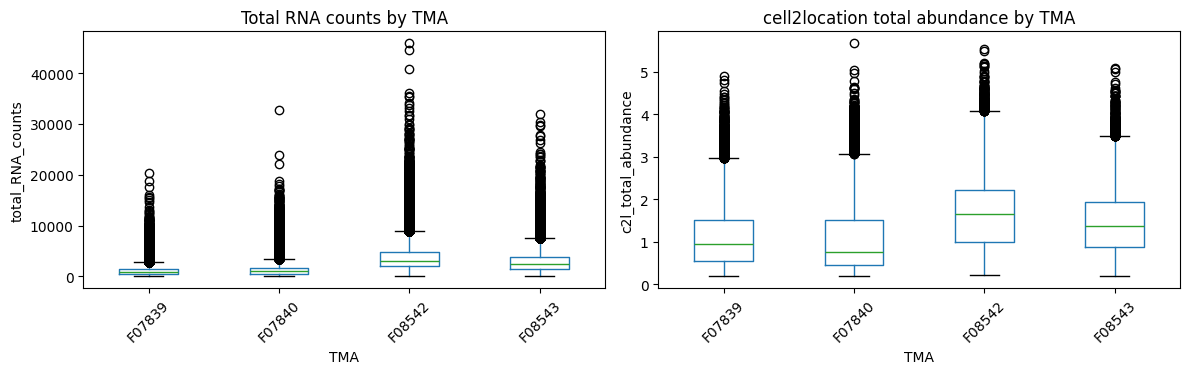

In [44]:
# %% Distribution and correlation check by TMA
rna_col = "total_RNA_counts" if "total_RNA_counts" in adata_vis.obs.columns else "total RNA counts"

for tma, df in adata_vis.obs.groupby("TMA", observed=True):
    spearman = df[rna_col].corr(df["c2l_total_abundance"], method="spearman")
    print(
        f"{tma}: "
        f"RNA median={df[rna_col].median():.1f}, "
        f"RNA mean={df[rna_col].mean():.1f}, "
        f"c2l median={df['c2l_total_abundance'].median():.4f}, "
        f"c2l mean={df['c2l_total_abundance'].mean():.4f}, "
        f"Spearman(RNA vs c2l)={spearman:.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

adata_vis.obs.boxplot(column=rna_col, by="TMA", ax=axes[0], grid=False, rot=45)
axes[0].set_title("Total RNA counts by TMA")
axes[0].set_ylabel(rna_col)

adata_vis.obs.boxplot(column="c2l_total_abundance", by="TMA", ax=axes[1], grid=False, rot=45)
axes[1].set_title("cell2location total abundance by TMA")
axes[1].set_ylabel("c2l_total_abundance")

plt.suptitle("")
plt.tight_layout()
plt.show()